 SVM creates a decision boundary that maintains the largest possible gap between classes, making it a powerful tool for reliable classification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,         # Total number of samples
    n_features=2,          # Number of features
    n_informative=2,       # Number of informative features (contribute to the output)
    n_redundant=0,         # Number of redundant features (linear combinations of informative ones)
    n_repeated=0,          # Number of duplicated features
    n_classes=2,           # Number of classes (binary classification)
    n_clusters_per_class=1, # Number of clusters per class
    flip_y=0.01,           # Percentage of samples whose class is randomly flipped
    random_state=1        # For reproducibility
)

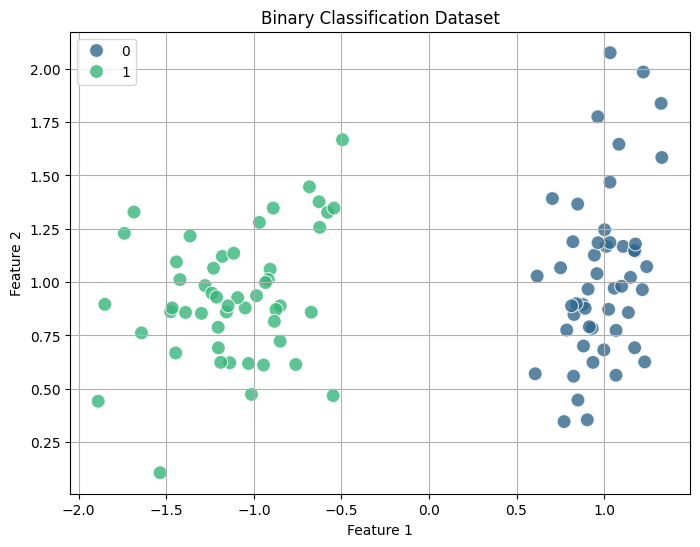

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', s=100, alpha=0.8)
plt.title('Binary Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SVM Linear

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for simplicity

# Train the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Model Accuracy: {accuracy:.4f}")

SVM Model Accuracy: 1.0000


In [ ]:
svm_model.support_vectors_

array([[ 0.60660431,  0.56998385],
       [ 0.61771419,  1.02817479],
       [-0.5789623 ,  1.32720112],
       [-0.76045809,  0.61363671],
       [-0.54245992,  1.34740825]])

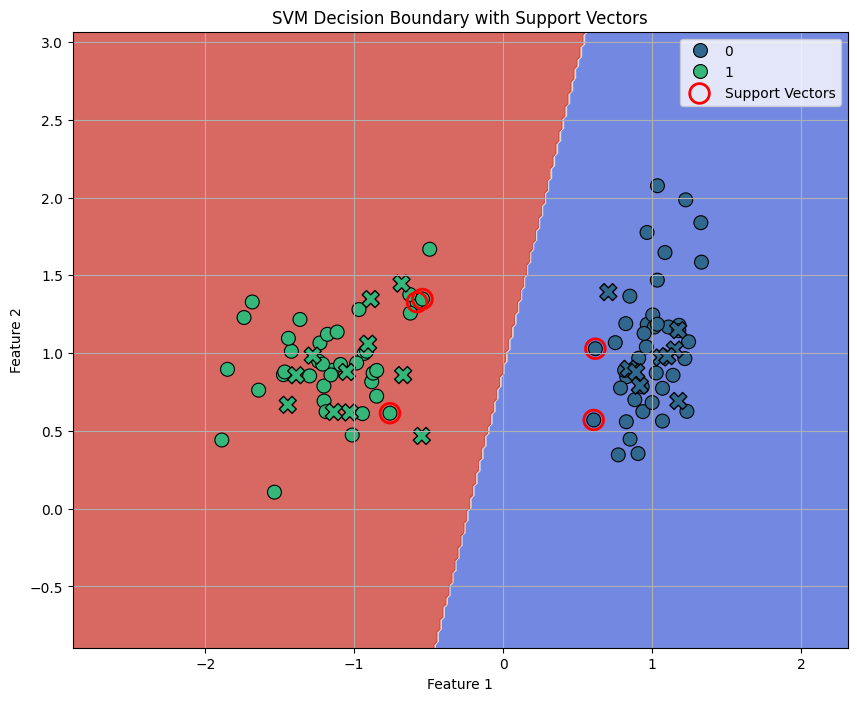

In [ ]:
# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points (removed 'label' argument)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the testing points (removed 'label' argument)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False)

# Plot the support vectors
plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.title('SVM Decision Boundary with Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## SVM Polynomial

In [ ]:
# Initialize the SVM classifier with a polynomial kernel
# You can specify the degree of the polynomial, e.g., degree=2, degree=3
svm_poly_model = SVC(kernel='poly', degree=3, random_state=42)

# Train the model on the training data
svm_poly_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_poly = svm_poly_model.predict(X_test)

# Evaluate the model's accuracy
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Polynomial SVM Model Accuracy (degree=3): {accuracy_poly:.4f}")

Polynomial SVM Model Accuracy (degree=3): 0.9500


In [ ]:
svm_poly_model.support_vectors_

array([[ 0.60660431,  0.56998385],
       [ 0.90394545,  0.35413361],
       [ 0.77151441,  0.345716  ],
       [ 0.85063796,  0.44689516],
       [ 0.82550695,  0.55853873],
       [-0.94495995,  0.6109426 ],
       [-1.01366961,  0.47330777],
       [-0.76045809,  0.61363671],
       [-0.88286982,  0.81583612],
       [-0.84983074,  0.72297801]])

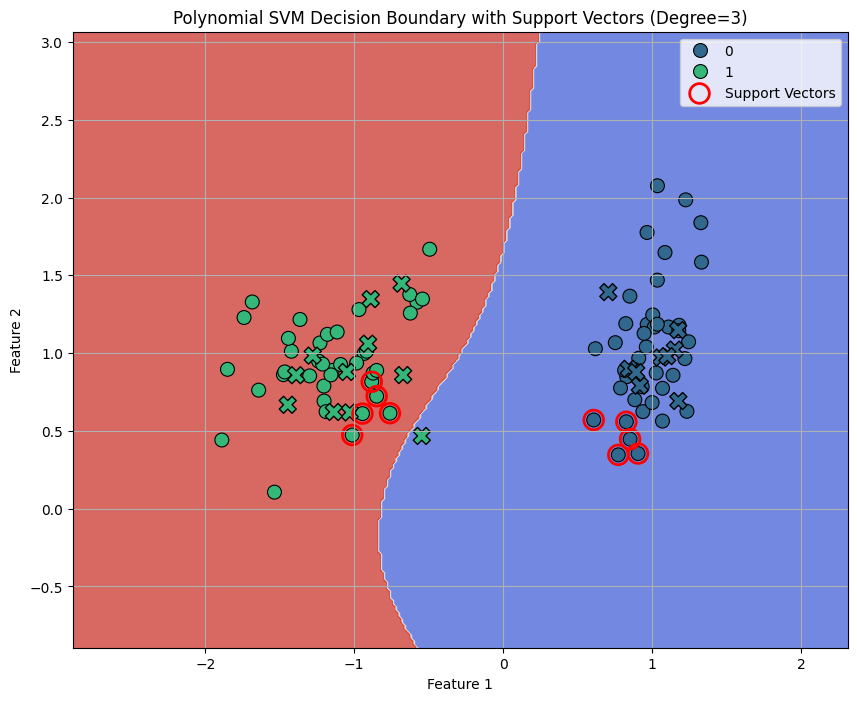

In [ ]:
# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh using the polynomial SVM model
Z_poly = svm_poly_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_poly = Z_poly.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_poly, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the testing points
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False)

# Plot the support vectors for the polynomial SVM model
plt.scatter(svm_poly_model.support_vectors_[:, 0], svm_poly_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.title('Polynomial SVM Decision Boundary with Support Vectors (Degree=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## SVM RBF

In [ ]:
# Initialize the SVM classifier with an RBF kernel
svm_rbf_model = SVC(kernel='rbf', random_state=42)

# Train the model on the training data
svm_rbf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rbf = svm_rbf_model.predict(X_test)

# Evaluate the model's accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM Model Accuracy: {accuracy_rbf:.4f}")

RBF SVM Model Accuracy: 1.0000


In [ ]:
svm_rbf_model.support_vectors_

array([[ 0.60660431,  0.56998385],
       [ 1.03436581,  2.07582971],
       [ 0.61771419,  1.02817479],
       [-0.493857  ,  1.66752297],
       [-0.76045809,  0.61363671],
       [-1.88873982,  0.44118981],
       [-1.53556118,  0.10593645],
       [-0.54245992,  1.34740825]])

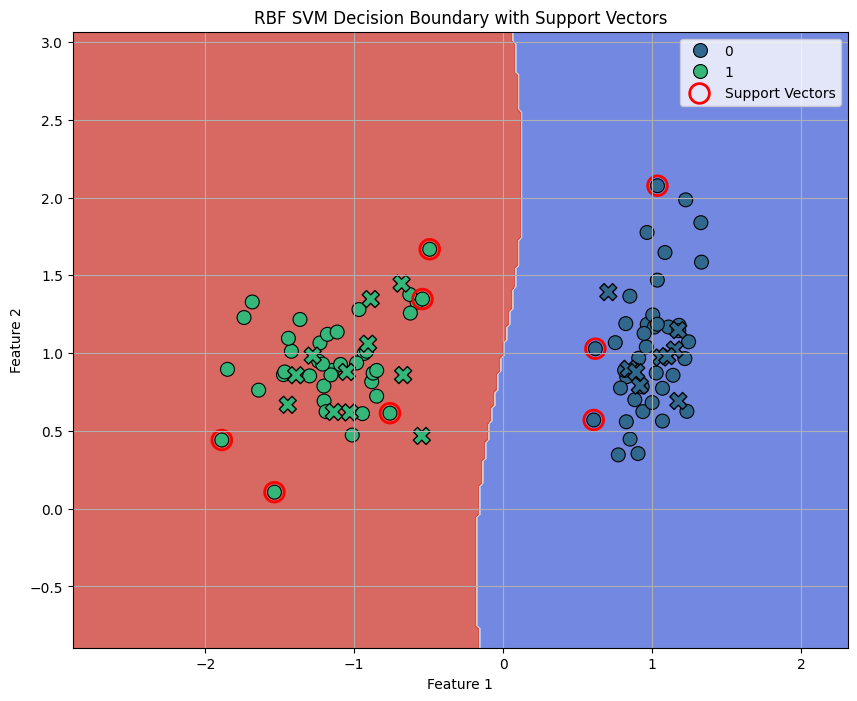

In [ ]:
# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh using the RBF SVM model
Z_rbf = svm_rbf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the testing points
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False)

# Plot the support vectors for the RBF SVM model
plt.scatter(svm_rbf_model.support_vectors_[:, 0], svm_rbf_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.title('RBF SVM Decision Boundary with Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## SVM Sigmoid

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier with a sigmoid kernel
svm_sigmoid_model = SVC(kernel='sigmoid', random_state=42)

# Train the model on the training data
svm_sigmoid_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_sigmoid = svm_sigmoid_model.predict(X_test)

# Evaluate the model's accuracy
accuracy_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
print(f"Sigmoid SVM Model Accuracy: {accuracy_sigmoid:.4f}")

Sigmoid SVM Model Accuracy: 1.0000


In [ ]:
svm_sigmoid_model.support_vectors_

array([[ 1.32551412,  1.838294  ],
       [ 0.96435056,  1.77547698],
       [ 1.22382712,  1.98519313],
       [ 1.08480038,  1.64661853],
       [ 1.03436581,  2.07582971],
       [-0.5789623 ,  1.32720112],
       [-0.493857  ,  1.66752297],
       [-0.62754626,  1.37661405],
       [-0.54245992,  1.34740825],
       [-0.62373281,  1.25704434]])

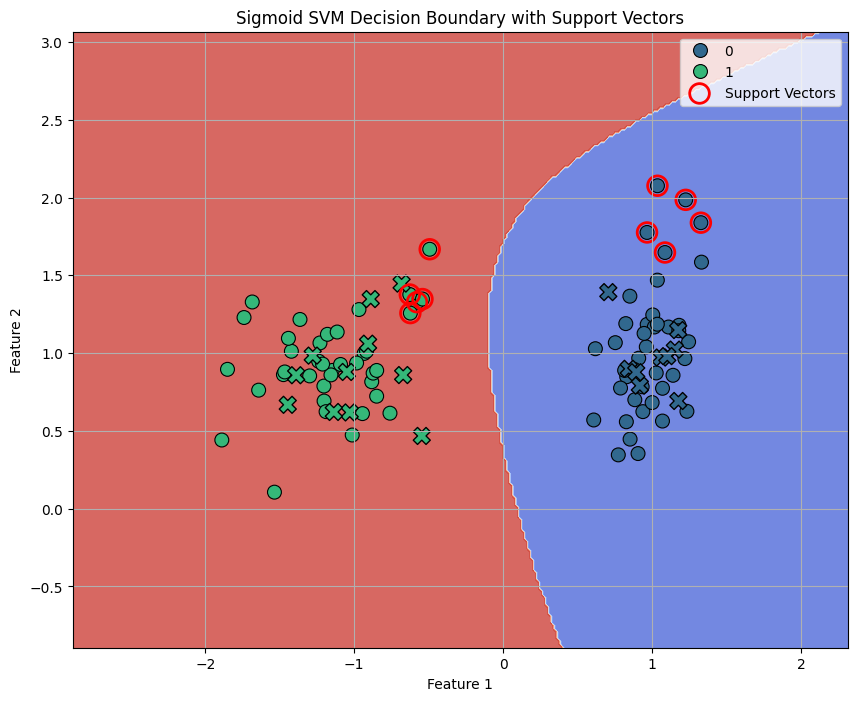

In [ ]:
# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.02  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the mesh using the Sigmoid SVM model
Z_sigmoid = svm_sigmoid_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sigmoid = Z_sigmoid.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_sigmoid, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot the training points
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k')

# Plot the testing points
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False)

# Plot the support vectors for the Sigmoid SVM model
plt.scatter(svm_sigmoid_model.support_vectors_[:, 0], svm_sigmoid_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

plt.title('Sigmoid SVM Decision Boundary with Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Compare All of Them

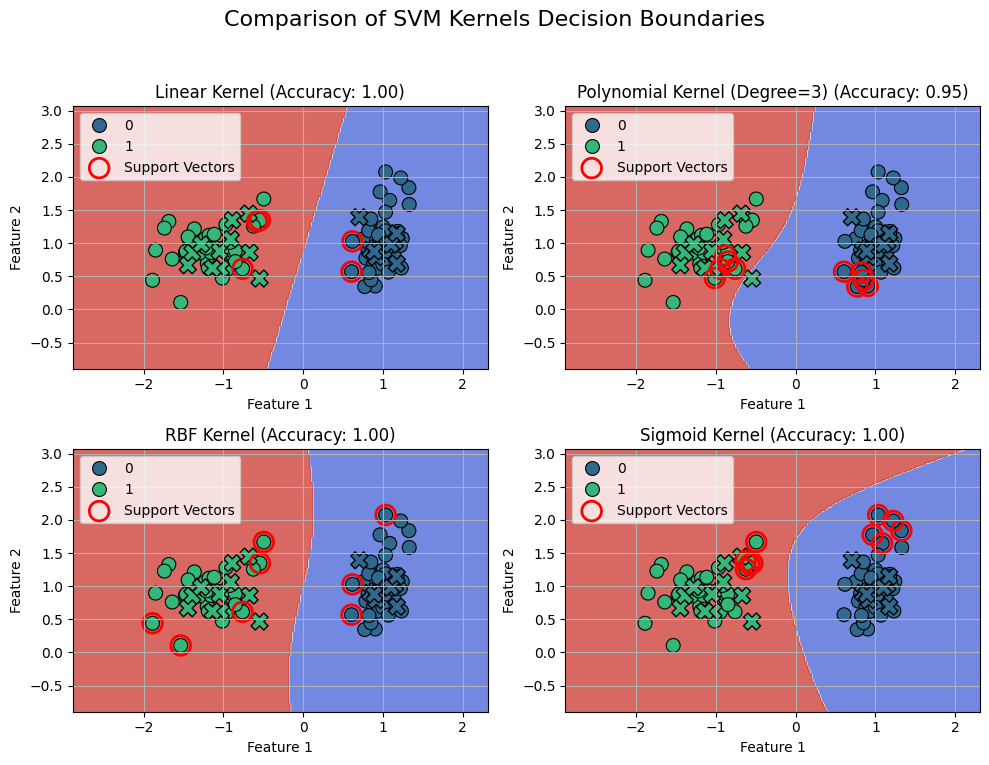

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Comparison of SVM Kernels Decision Boundaries', fontsize=16)

# Linear SVM
axes[0, 0].contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k', ax=axes[0, 0])
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False, ax=axes[0, 0])
axes[0, 0].scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')
axes[0, 0].set_title(f'Linear Kernel (Accuracy: {accuracy:.2f})')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].grid(True)

# Polynomial SVM
axes[0, 1].contourf(xx, yy, Z_poly, cmap=plt.cm.coolwarm, alpha=0.8)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k', ax=axes[0, 1])
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False, ax=axes[0, 1])
axes[0, 1].scatter(svm_poly_model.support_vectors_[:, 0], svm_poly_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')
axes[0, 1].set_title(f'Polynomial Kernel (Degree=3) (Accuracy: {accuracy_poly:.2f})')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].grid(True)

# RBF SVM
axes[1, 0].contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.8)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k', ax=axes[1, 0])
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False, ax=axes[1, 0])
axes[1, 0].scatter(svm_rbf_model.support_vectors_[:, 0], svm_rbf_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')
axes[1, 0].set_title(f'RBF Kernel (Accuracy: {accuracy_rbf:.2f})')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')
axes[1, 0].grid(True)

# Sigmoid SVM
axes[1, 1].contourf(xx, yy, Z_sigmoid, cmap=plt.cm.coolwarm, alpha=0.8)
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train,
                palette='viridis', marker='o', s=100, edgecolor='k', ax=axes[1, 1])
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                palette='viridis', marker='X', s=150, edgecolor='k', legend=False, ax=axes[1, 1])
axes[1, 1].scatter(svm_sigmoid_model.support_vectors_[:, 0], svm_sigmoid_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')
axes[1, 1].set_title(f'Sigmoid Kernel (Accuracy: {accuracy_sigmoid:.2f})')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt


def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = svm.SVC(kernel=kernel, gamma=2).fit(X, y)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -2, 2, -1, 3
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter_plot = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors="k")
    ax.legend(*scatter_plot.legend_elements(), loc="upper right", title="Classes")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()

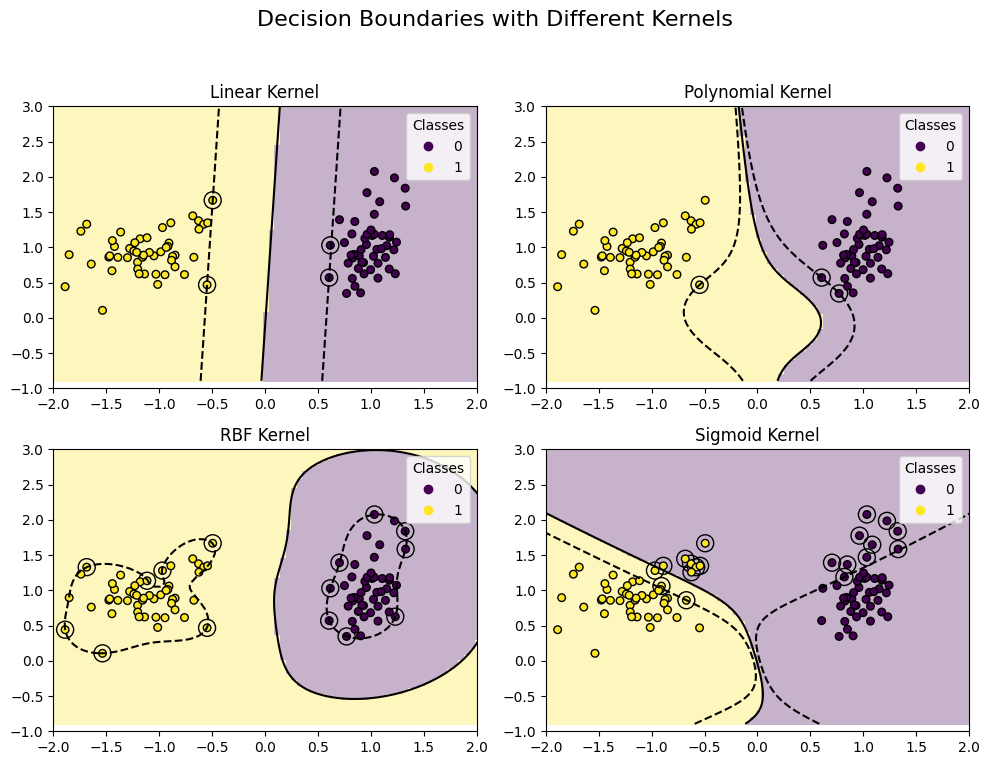

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Decision Boundaries with Different Kernels', fontsize=16)

# Linear Kernel
plot_training_data_with_decision_boundary(kernel='linear', ax=axes[0, 0], long_title=False)
axes[0, 0].set_title('Linear Kernel')

# Polynomial Kernel
plot_training_data_with_decision_boundary(kernel='poly', ax=axes[0, 1], long_title=False)
axes[0, 1].set_title('Polynomial Kernel')

# RBF Kernel
plot_training_data_with_decision_boundary(kernel='rbf', ax=axes[1, 0], long_title=False)
axes[1, 0].set_title('RBF Kernel')

# Sigmoid Kernel
plot_training_data_with_decision_boundary(kernel='sigmoid', ax=axes[1, 1], long_title=False)
axes[1, 1].set_title('Sigmoid Kernel')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()